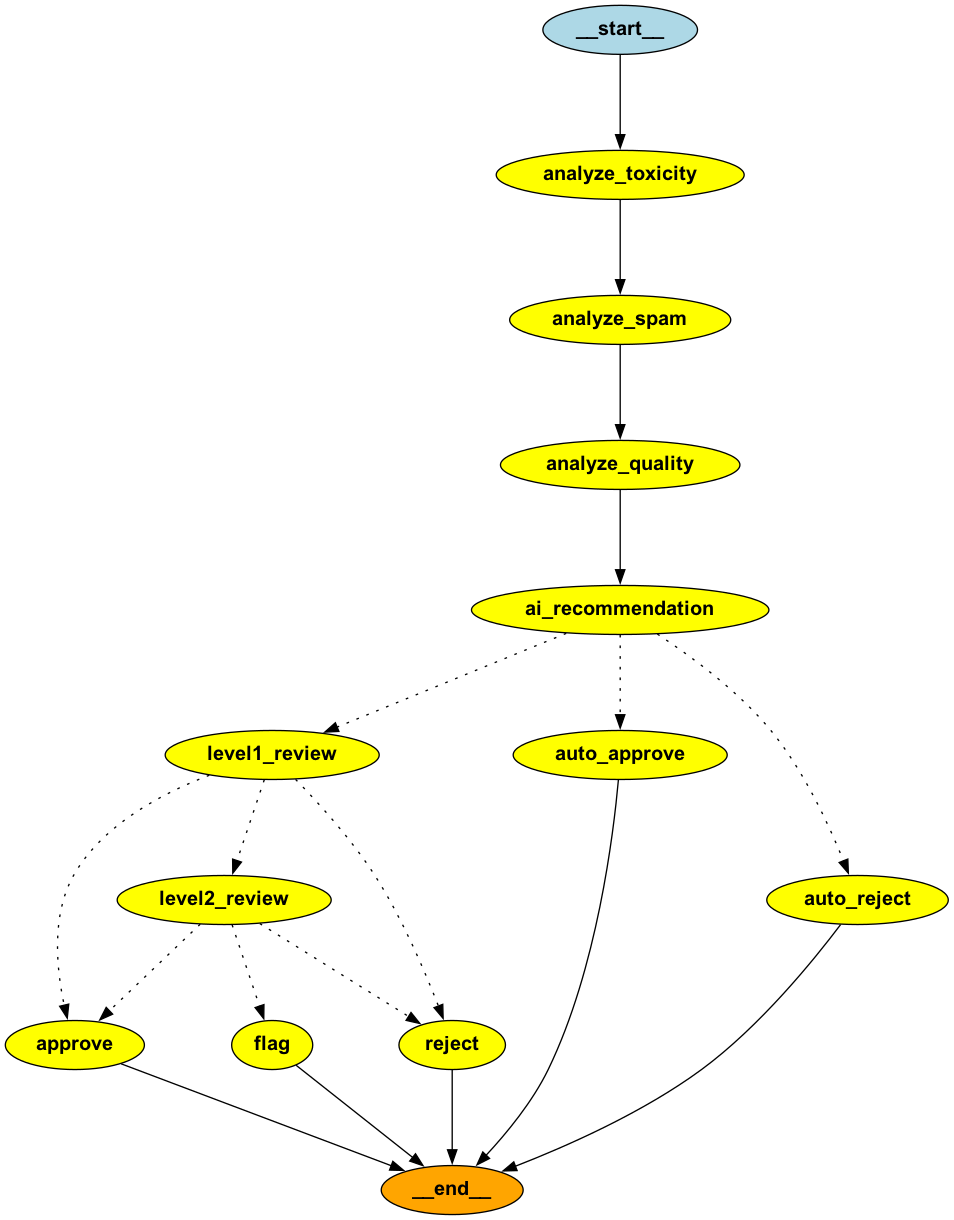

In [4]:
from LangGraph.envInit import display_graph, model

"""
综合实战：交互式内容审核工作流

功能：
- 自动内容分析
- 流式输出分析进度
- 多级人工审核（Interrupts）
- 历史追溯（Time Travel）
- 可撤销决策
"""

from typing import TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt
from langchain.messages import HumanMessage, SystemMessage
import sqlite3
import json
import time


class ContentReviewState(TypedDict):
    # 内容信息
    content_id: str
    content: str
    content_type: str  # "article", "comment", "post"

    # 分析结果
    toxicity_score: float
    spam_score: float
    quality_score: float
    ai_recommendation: str

    # 审核流程
    review_level: int  # 1, 2, 3
    reviewer_decisions: Annotated[list, lambda old, new: old + new]
    final_decision: str  # "approved", "rejected", "flagged"

    # 元数据
    processing_steps: Annotated[list, lambda old, new: old + new]
    created_at: str
    reviewed_at: str


# 分析节点
def analyze_toxicity(state: ContentReviewState) -> dict:
    """分析毒性"""
    print("🔍 分析毒性...")
    time.sleep(0.5)

    content = state["content"]

    prompt = f"""
        分析以下内容的毒性（0.0-1.0）：
        {content}
        只返回数字。
        """

    try:
        response = model.invoke([HumanMessage(content=prompt)])
        score = float(response.content.strip())
    except:
        score = 0.0

    return {
        "toxicity_score": min(max(score, 0.0), 1.0),
        "processing_steps": ["分析毒性完成"]
    }


def analyze_spam(state: ContentReviewState) -> dict:
    """分析垃圾信息"""
    print("🔍 分析垃圾信息...")
    time.sleep(0.5)

    content = state["content"]

    prompt = f"""
        分析以下内容是否为垃圾信息（0.0-1.0）：
        {content}

        只返回数字。
        """

    try:
        response = model.invoke([HumanMessage(content=prompt)])
        score = float(response.content.strip())
    except:
        score = 0.0

    return {
        "spam_score": min(max(score, 0.0), 1.0),
        "processing_steps": ["分析垃圾信息完成"]
    }


def analyze_quality(state: ContentReviewState) -> dict:
    """分析质量"""
    print("🔍 分析内容质量...")
    time.sleep(0.5)

    content = state["content"]

    prompt = f"""
        分析以下内容的质量（0.0-1.0）：
        {content}
        只返回数字。
        """

    try:
        response = model.invoke([HumanMessage(content=prompt)])
        score = float(response.content.strip())
    except:
        score = 0.0

    return {
        "quality_score": min(max(score, 0.0), 1.0),
        "processing_steps": ["分析内容质量完成"]
    }


def make_ai_recommendation(state: ContentReviewState) -> dict:
    """AI 综合建议"""
    print("🤖 生成 AI 建议...")

    toxicity = state["toxicity_score"]
    spam = state["spam_score"]
    quality = state["quality_score"]

    # 规则基于的建议
    if toxicity > 0.7 or spam > 0.7:
        recommendation = "auto_reject"
    elif toxicity < 0.3 and spam < 0.3 and quality > 0.6:
        recommendation = "auto_approve"
    else:
        recommendation = "human_review"

    return {
        "ai_recommendation": recommendation,
        "processing_steps": ["AI 建议生成完成"]
    }


# ======================
# 路由决策
# ======================
def route_by_ai_recommendation(state: ContentReviewState) -> Literal["auto_approve", "auto_reject", "level1_review"]:
    """根据 AI 建议路由"""
    recommendation = state["ai_recommendation"]

    if recommendation == "auto_approve":
        return "auto_approve"
    elif recommendation == "auto_reject":
        return "auto_reject"
    else:
        return "level1_review"


def route_after_level1(state: ContentReviewState) -> Literal["approve", "level2_review", "reject"]:
    """一级审核后路由"""
    decisions = state.get("reviewer_decisions", [])
    if len(decisions) == 0:
        return "level2_review"

    last_decision = decisions[-1]["decision"]

    if last_decision == "approve":
        return "approve"
    elif last_decision == "escalate":
        return "level2_review"
    else:
        return "reject"


def route_after_level2(state: ContentReviewState) -> Literal["approve", "reject", "flag"]:
    """二级审核后路由"""
    decisions = state.get("reviewer_decisions", [])
    if len(decisions) < 2:
        return "flag"

    last_decision = decisions[-1]["decision"]

    if last_decision == "approve":
        return "approve"
    elif last_decision == "flag":
        return "flag"
    else:
        return "reject"


# ======================
# 审核节点
# ======================
def level1_review_node(state: ContentReviewState) -> dict:
    """一级审核（Interrupt）"""
    print("\n" + "=" * 60)
    print("📋 一级审核")
    print("=" * 60)
    print(f"内容: {state['content']}")
    print(f"毒性分数: {state['toxicity_score']:.2f}")
    print(f"垃圾分数: {state['spam_score']:.2f}")
    print(f"质量分数: {state['quality_score']:.2f}")
    print("=" * 60 + "\n")

    # 中断，等待审核决策
    decision = interrupt({
        "type": "level1_review",
        "content": state["content"],
        "scores": {
            "toxicity": state["toxicity_score"],
            "spam": state["spam_score"],
            "quality": state["quality_score"]
        },
        "options": ["approve", "escalate", "reject"]
    })

    return {
        "review_level": 1,
        "reviewer_decisions": [{
            "level": 1,
            "decision": decision,
            "timestamp": time.time()
        }],
        "processing_steps": ["一级审核完成"]
    }


def level2_review_node(state: ContentReviewState) -> dict:
    """二级审核（高级）"""
    print("\n" + "=" * 60)
    print("📋 二级审核（高级）")
    print("=" * 60)
    print(f"内容: {state['content']}")
    print(f"一级审核决策: {state['reviewer_decisions']}")
    print("=" * 60 + "\n")

    decision = interrupt({
        "type": "level2_review",
        "content": state["content"],
        "previous_decisions": state["reviewer_decisions"],
        "options": ["approve", "reject", "flag"]
    })

    return {
        "review_level": 2,
        "reviewer_decisions": [{
            "level": 2,
            "decision": decision,
            "timestamp": time.time()
        }],
        "processing_steps": ["二级审核完成"]
    }


# ======================
# 最终处理节点
# ======================
def auto_approve_node(state: ContentReviewState) -> dict:
    """自动批准"""
    print("✅ 自动批准")
    return {
        "final_decision": "approved",
        "processing_steps": ["自动批准"]
    }


def auto_reject_node(state: ContentReviewState) -> dict:
    """自动拒绝"""
    print("❌ 自动拒绝")
    return {
        "final_decision": "rejected",
        "processing_steps": [" "]
    }


def approve_node(state: ContentReviewState) -> dict:
    """批准"""
    print("✅ 人工批准")
    return {
        "final_decision": "approved",
        "processing_steps": ["人工批准"]
    }


def reject_node(state: ContentReviewState) -> dict:
    """拒绝"""
    print("❌ 人工拒绝")
    return {
        "final_decision": "rejected",
        "processing_steps": ["人工拒绝"]
    }


def flag_node(state: ContentReviewState) -> dict:
    """标记"""
    print("▶ 标记为可疑")
    return {
        "final_decision": "flagged",
        "processing_steps": ["标记可疑"]
    }


# ======================
# 构建图
# ======================
review_graph = StateGraph(ContentReviewState)

# 分析节点
review_graph.add_node("analyze_toxicity", analyze_toxicity)
review_graph.add_node("analyze_spam", analyze_spam)
review_graph.add_node("analyze_quality", analyze_quality)
review_graph.add_node("ai_recommendation", make_ai_recommendation)

# 审核节点
review_graph.add_node("level1_review", level1_review_node)
review_graph.add_node("level2_review", level2_review_node)

# 决策节点
review_graph.add_node("auto_approve", auto_approve_node)
review_graph.add_node("auto_reject", auto_reject_node)
review_graph.add_node("approve", approve_node)
review_graph.add_node("reject", reject_node)
review_graph.add_node("flag", flag_node)

# 构建流程
review_graph.add_edge(START, "analyze_toxicity")
review_graph.add_edge("analyze_toxicity", "analyze_spam")
review_graph.add_edge("analyze_spam", "analyze_quality")
review_graph.add_edge("analyze_quality", "ai_recommendation")

review_graph.add_conditional_edges(
    "ai_recommendation",
    route_by_ai_recommendation,
    {
        "auto_approve": "auto_approve",
        "auto_reject": "auto_reject",
        "level1_review": "level1_review"
    }
)

review_graph.add_conditional_edges(
    "level1_review",
    route_after_level1,
    {
        "approve": "approve",
        "level2_review": "level2_review",
        "reject": "reject"
    }
)

review_graph.add_conditional_edges(
    "level2_review",
    route_after_level2,
    {
        "approve": "approve",
        "reject": "reject",
        "flag": "flag"
    }
)

# 所有终点流向 END
for node in ["auto_approve", "auto_reject", "approve", "reject", "flag"]:
    review_graph.add_edge(node, END)

# 编译（使用 SQLite checkpointer）
checkpointer = SqliteSaver(sqlite3.connect("content_review.db", check_same_thread=False))
review_app = review_graph.compile(checkpointer=checkpointer)

display_graph(review_app)

In [5]:
# 使用示例
def run_review_demo():
    """运行审核演示"""
    print("\n" + "=" * 60)
    print("交互式内容审核工作流演示")
    print("=" * 60 + "\n")

    # 测试内容
    test_content = "这是一条需要审核的用户评论。内容质量较好，没有明显问题。"

    config = {"configurable": {"thread_id": "review-001"}}

    # 初始运行（会在一级审核时中断）
    print("🚀 开始审核流程...\n")

    initial_state = {
        "content_id": "content-001",
        "content": test_content,
        "content_type": "comment",
        "toxicity_score": 0.0,
        "spam_score": 0.0,
        "quality_score": 0.0,
        "ai_recommendation": "",
        "review_level": 0,
        "reviewer_decisions": [],
        "final_decision": "",
        "processing_steps": [],
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "reviewed_at": ""
    }

    # Stream 运行，显示进度
    for chunk in review_app.stream(initial_state, config, stream_mode="updates"):
        for node_name, update in chunk.items():
            if update and "processing_steps" in update:
                steps = update["processing_steps"]
                for step in steps:
                    print(f"  ✓ {step}")

    # 检查状态
    state = review_app.get_state(config)
    print(f"\n当前状态: 等待 {state.next}")

    # 模拟一级审核决策
    print("\n👤 审核员决策: escalate（提交二级审核）")
    review_app.update_state(
        config,
        {
            "reviewer_decisions": [
                {
                    "level": 1,
                    "decision": "escalate",
                    "timestamp": time.time()
                }
            ]
        },
        as_node="level1_review"
    )

    # 继续执行
    print("\n继续执行...\n")
    for chunk in review_app.stream(None, config, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"  节点: {node_name}")

    # 查看历史
    print("\n" + "=" * 60)
    print("📜 执行历史")
    print("=" * 60)

    history = list(review_app.get_state_history(config))
    print(f"总共 {len(history)} 个检查点")

    for i, checkpoint in enumerate(history[:5]):  # 显示前5个
        print(f"\nCheckpoint {i + 1}:")
        print(f"  决策: {checkpoint.values.get('final_decision', '进行中')}")
        print(
            f"  步骤: {checkpoint.values.get('processing_steps', [])[-1] if checkpoint.values.get('processing_steps') else 'N/A'}")

    print("\n" + "=" * 60)
    print("✅ 演示完成")
    print("=" * 60 + "\n")


if __name__ == "__main__":
    run_review_demo()


交互式内容审核工作流演示

🚀 开始审核流程...

🔍 分析毒性...
  ✓ 分析毒性完成
🔍 分析垃圾信息...
  ✓ 分析垃圾信息完成
🔍 分析内容质量...
  ✓ 分析内容质量完成
🤖 生成 AI 建议...
  ✓ AI 建议生成完成

📋 一级审核
内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。
毒性分数: 0.00
垃圾分数: 0.00
质量分数: 0.50


当前状态: 等待 ('level1_review',)

👤 审核员决策: escalate（提交二级审核）

继续执行...


📋 二级审核（高级）
内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。
一级审核决策: [{'level': 1, 'decision': 'escalate', 'timestamp': 1782306785.264896}]

  节点: __interrupt__

📜 执行历史
总共 12 个检查点

Checkpoint 1:
  决策: 
  步骤: AI 建议生成完成

Checkpoint 2:
  决策: 
  步骤: AI 建议生成完成

Checkpoint 3:
  决策: 
  步骤: 分析内容质量完成

Checkpoint 4:
  决策: 
  步骤: 分析垃圾信息完成

Checkpoint 5:
  决策: 
  步骤: 分析毒性完成

✅ 演示完成

